# 1. Install dependencies


In [ ]:
#!pip install transformers trl accelerate datasets peft bitsandbytes torch

In [4]:
#from huggingface_hub import login
#login()

# 2. Imports


In [5]:
import re
import torch
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType
from trl import GRPOConfig, GRPOTrainer

print(f'torch  : {torch.__version__}')
print(f'CUDA   : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f'GPU    : {gpu_name}')
    if 'P100' not in gpu_name and 'V100' not in gpu_name:
        print('⚠  WARNING: This notebook is tuned for P100 16 GB. '
              'Adjust batch sizes if you are on a different GPU.')

torch  : 2.10.0+cu128
CUDA   : True
GPU    : Tesla T4
⚠  WARNING: This notebook is tuned for P100 16 GB. Adjust batch sizes if you are on a different GPU.


# 3. Load SVAMP dataset


In [6]:
from datasets import load_dataset

dataset = load_dataset("ChilleD/SVAMP")

print(dataset)

print(dataset["train"][0])

README.md:   0%|          | 0.00/675 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/111k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/54.8k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/700 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/300 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['ID', 'Body', 'Question', 'Equation', 'Answer', 'Type', 'question_concat'],
        num_rows: 700
    })
    test: Dataset({
        features: ['ID', 'Body', 'Question', 'Equation', 'Answer', 'Type', 'question_concat'],
        num_rows: 300
    })
})
{'ID': 'chal-777', 'Body': "There are 87 oranges and 290 bananas in Philip's collection. If the bananas are organized into 2 groups and oranges are organized into 93 groups", 'Question': 'How big is each group of bananas?', 'Equation': '( 290.0 / 2.0 )', 'Answer': '145', 'Type': 'Common-Division', 'question_concat': "There are 87 oranges and 290 bananas in Philip's collection. If the bananas are organized into 2 groups and oranges are organized into 93 groups How big is each group of bananas?"}


# 4. Format SVAMP into chat prompts


In [7]:

QUESTION_COL = 'question_concat'
ANSWER_COL   = 'Answer'

SYSTEM_PROMPT = (
    'You are a helpful assistant. '
    'Always reason step-by-step inside <think>...</think> tags, '
    'then give your final answer inside <answer>...</answer> tags.'
)

def to_chat(example):
    return {
        "prompt": [
            {
                "role": "user",
                "content":
                    "You MUST follow this format exactly.\n"
                    "Do not write anything outside tags.\n\n"
                    "<think>reason step by step</think>\n"
                    "<answer>final numeric answer only</answer>\n\n"
                    "Problem:\n"
                    + example["question_concat"]
            }
        ],
        "answer": str(example["Answer"]),
    }
# Use your dataset variable
train_ds = dataset["train"].map(
    to_chat,
    remove_columns=dataset["train"].column_names
)

eval_ds = dataset["test"].map(
    to_chat,
    remove_columns=dataset["test"].column_names
)

print(f'Train: {len(train_ds)} | Eval: {len(eval_ds)}')

print('\nSample prompt:')
print(train_ds[0]['prompt'])

print('\nExpected answer:')
print(train_ds[0]['answer'])

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Train: 700 | Eval: 300

Sample prompt:
[{'content': "You MUST follow this format exactly.\nDo not write anything outside tags.\n\n<think>reason step by step</think>\n<answer>final numeric answer only</answer>\n\nProblem:\nThere are 87 oranges and 290 bananas in Philip's collection. If the bananas are organized into 2 groups and oranges are organized into 93 groups How big is each group of bananas?", 'role': 'user'}]

Expected answer:
145


# 5. Reward functions


In [8]:
def extract_answer(text):
    """Extract the content inside the last <answer>...</answer> block."""
    matches = re.findall(r"<answer>\s*(.*?)\s*</answer>", text, re.DOTALL | re.IGNORECASE)
    if not matches:
        return None
    return matches[-1].strip()

def clean_number(s):
    """Strip common non-numeric decoration and return a float, or None."""
    if s is None:
        return None
    s = re.sub(r"[\$,£€%]", "", s).strip().rstrip(".")
    m = re.search(r"-?\d+(?:\.\d+)?", s)
    if not m:
        return None
    try:
        return float(m.group())
    except ValueError:
        return None

def answers_match(pred, gt):
    """True when pred and gt represent the same number (with small tolerance)."""
    pv, gv = clean_number(pred), clean_number(gt)
    if pv is None or gv is None:
        return False
    tol = max(1e-6, abs(gv) * 1e-4)
    return abs(pv - gv) <= tol

def format_reward(completions, **kwargs):
    """Award up to 1.0 for correct <think>...</think><answer>...</answer> structure."""
    rewards = []
    for c in completions:
        text = c[0]["content"]
        has_think  = "<think>"  in text and "</think>"  in text
        has_answer = "<answer>" in text and "</answer>" in text
        # Bonus 0.2 if nothing is written outside the tags (clean format)
        outside_tags = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)
        outside_tags = re.sub(r"<answer>.*?</answer>", "", outside_tags, flags=re.DOTALL).strip()
        clean_bonus  = 0.2 if (has_think and has_answer and outside_tags == "") else 0.0
        score = (0.4 * has_think) + (0.4 * has_answer) + clean_bonus
        rewards.append(round(score, 4))
    return rewards

def correctness_reward(completions, answer, **kwargs):
    """
    +2.0 for exact match, +0.5 for close answer, -0.5 for wrong, -1.0 for no answer.
    Wider range gives GRPO a stronger gradient signal.
    """
    rewards = []
    for c, gt in zip(completions, answer):
        text = c[0]["content"]
        pred = extract_answer(text)

        if pred is None:
            rewards.append(-1.0)
            continue

        pv = clean_number(pred)
        gv = clean_number(gt)

        if pv is None or gv is None:
            rewards.append(-0.5)
            continue

        if answers_match(pred, gt):
            rewards.append(2.0)
        else:
            denom = max(abs(gv), 1.0)
            closeness = max(0.0, 1.0 - abs(pv - gv) / denom)
            # Scaled: 0 → -0.5, 0.9 → +0.4  (positive only when very close)
            rewards.append(round(closeness * 1.0 - 0.5, 4))

    return rewards


# 6. Load model (Gemma 2 2B, 4-bit)


In [9]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_ID = "google/gemma-2-2b-it"

# Better config for T4 (supports FP16 well)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,   # T4 works great with FP16
    bnb_4bit_use_double_quant=True,
)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

# Model
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",            # uses both T4 GPUs if available
    torch_dtype=torch.float16,
    attn_implementation="sdpa",   # faster than 'eager' on T4
)

model.config.use_cache = False

print(model)

config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Gemma2ForCausalLM(
  (model): Gemma2Model(
    (embed_tokens): Gemma2TextScaledWordEmbedding(256000, 2304, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma2DecoderLayer(
        (self_attn): Gemma2Attention(
          (q_proj): Linear4bit(in_features=2304, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=2304, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=2304, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=2304, bias=False)
        )
        (mlp): Gemma2MLP(
          (gate_proj): Linear4bit(in_features=2304, out_features=9216, bias=False)
          (up_proj): Linear4bit(in_features=2304, out_features=9216, bias=False)
          (down_proj): Linear4bit(in_features=9216, out_features=2304, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (post_attention_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)


In [10]:
def run_inference(prompt_messages, max_new_tokens=384):
    """Greedy decoding for deterministic, high-quality answers."""
    text = tokenizer.apply_chat_template(
        prompt_messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,              # greedy – most reliable for math
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.1,       # discourage looping
        )

    generated = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True)


def evaluate(model, dataset, n=30):
    model.eval()
    correct = 0

    for i in range(min(n, len(dataset))):
        example = dataset[i]

        response = run_inference(example["prompt"])
        pred = extract_answer(response)
        gt = example["answer"]

        ok = answers_match(pred, gt)
        correct += int(ok)

    return correct, n


base_correct, total = evaluate(model, eval_ds, n=30)
print(f"BEFORE GRPO Accuracy: {base_correct}/{total} = {base_correct/total:.1%}")

BEFORE GRPO Accuracy: 13/30 = 43.3%


# 7. LoRA configuration


In [11]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,               # increased rank for more capacity
    lora_alpha=32,      # 2x r
    lora_dropout=0.05,
    bias="none",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",  # attention
        "gate_proj", "up_proj", "down_proj",       # MLP layers
    ],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 20,766,720 || all params: 2,635,108,608 || trainable%: 0.7881


# 8. GRPO Training Configuration


In [12]:
grpo_config = GRPOConfig(
    output_dir="./grpo_svamp",

    num_train_epochs=4,                    # more epochs for deeper learning
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,

    learning_rate=8e-6,                    # slightly higher LR
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,                      # longer warmup for stability

    num_generations=8,                     # more rollouts → better policy gradient estimate
    beta=0.005,                            # lighter KL penalty = more exploration

    fp16=False,                             # enable FP16 for faster training
    bf16=False,

    max_grad_norm=1.0,                     # normal gradient clipping
    max_completion_length=512,

    logging_steps=10,
    save_steps=50,
    report_to="none",
    seed=42,
)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


# 9. Build GRPOTrainer & train


In [13]:
# Use full training set for better coverage
train_ds_grpo = train_ds  # all ~700 examples

grpo_config.num_train_epochs = 2
grpo_config.num_generations  = 4


In [14]:
from accelerate import Accelerator

accelerator = Accelerator()
model = accelerator.prepare(model)

In [15]:
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[correctness_reward, format_reward],
    args=grpo_config,
    train_dataset=train_ds_grpo,
    eval_dataset=eval_ds,
)
trainer.train()


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'pad_token_id': 1}.


Step,Training Loss
10,0.003976
20,-0.014175
30,0.017507
40,0.017023
50,0.029628
60,-0.008877
70,0.019599
80,0.038528
90,0.019462
100,0.032875


TrainOutput(global_step=350, training_loss=0.017268260046839713, metrics={'train_runtime': 12819.604, 'train_samples_per_second': 0.109, 'train_steps_per_second': 0.027, 'total_flos': 0.0, 'train_loss': 0.017268260046839713})

# 10. Save the adapter


In [16]:
trainer.save_model('./grpo_gemma2_swamp_final')
tokenizer.save_pretrained('./grpo_gemma2_swamp_final')

print("Model saved.")

Model saved.


# 11. Evaluate on the test split


In [17]:
model.eval()

def run_inference(prompt_messages, max_new_tokens=384):
    """Greedy decoding for deterministic, high-quality answers."""
    text = tokenizer.apply_chat_template(
        prompt_messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,              # greedy – most reliable for math
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.1,       # discourage looping
        )

    generated = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True)


correct = 0
total = min(30, len(eval_ds))

for i in range(total):
    example = eval_ds[i]

    response = run_inference(example["prompt"])
    pred = extract_answer(response)
    gt   = example["answer"]

    ok = answers_match(pred, gt)
    correct += int(ok)

    if i < 5:
        q = example["prompt"][-1]["content"]
        print(f"Q: {q}")
        print(f"Response : {response}")
        print(f"Predicted: {pred} | GT: {gt} | {'✓' if ok else '✗'}")
        print("-" * 50)

print(f"\nAccuracy: {correct}/{total} = {correct/total:.1%}")


Q: You MUST follow this format exactly.
Do not write anything outside tags.

<think>reason step by step</think>
<answer>final numeric answer only</answer>

Problem:
Winter is almost here and most animals are migrating to warmer countries. There are 41 bird families living near the mountain. If 35 bird families flew away to asia and 62 bird families flew away to africa How many more bird families flew away to africa than those that flew away to asia?
Response : <think>
1. **Find the total number of birds that flew to Asia:** 35 bird families
2. **Find the total number of birds that flew to Africa:** 62 bird families
3. **Subtract the number of birds that flew to Asia from the number that flew to Africa:** 62 - 35 = 27
</think>
<answer>27</answer> 

Predicted: 27 | GT: 27 | ✓
--------------------------------------------------
Q: You MUST follow this format exactly.
Do not write anything outside tags.

<think>reason step by step</think>
<answer>final numeric answer only</answer>

Problem:

In [18]:
after_correct, total = evaluate(model, eval_ds, n=30)
print(f"AFTER GRPO Accuracy: {after_correct}/{total} = {after_correct/total:.1%}")

AFTER GRPO Accuracy: 22/30 = 73.3%


# 12. Plot reward curves


Available columns: ['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/correctness_reward/mean', 'rewards/correctness_reward/std', 'rewards/format_reward/mean', 'rewards/format_reward/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'kl', 'entropy', 'clip_ratio/low_mean', 'clip_ratio/low_min', 'clip_ratio/high_mean', 'clip_ratio/high_max', 'clip_ratio/region_mean', 'step_time', 'epoch', 'step', 'train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss']


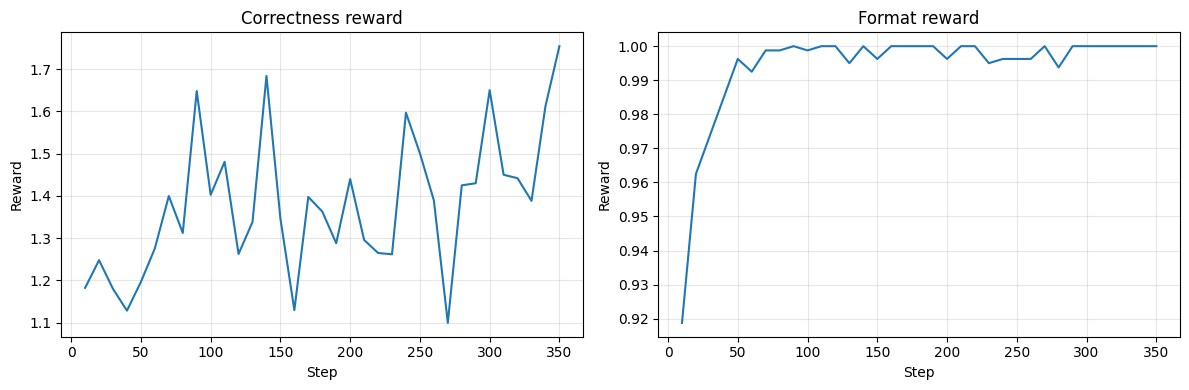

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

log = pd.DataFrame(trainer.state.log_history)

print("Available columns:", log.columns.tolist())

# TRL may log rewards under slightly different names depending on version.
# This helper tries both a direct match and a substring match.
def find_col(df, keyword):
    """Return the first column containing `keyword`, or None."""
    for col in df.columns:
        if keyword in col:
            return col
    return None

def plot_reward(keyword, ax, title):
    col = find_col(log, keyword)
    if col:
        data = log.dropna(subset=[col])
        if len(data) > 0:
            ax.plot(data["step"], data[col], linewidth=1.5)
            ax.set_title(title)
            ax.set_xlabel("Step")
            ax.set_ylabel("Reward")
            ax.grid(alpha=0.3)
            return
    ax.text(0.5, 0.5, "No data recorded", ha="center", va="center",
            transform=ax.transAxes, color="grey")
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_reward("correctness_reward", axes[0], "Correctness reward")
plot_reward("format_reward",      axes[1], "Format reward")

plt.tight_layout()
plt.savefig("reward_curves.png", dpi=120)
plt.show()


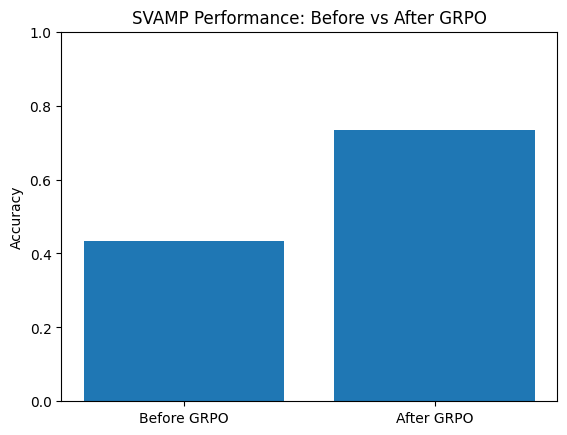

In [20]:
import matplotlib.pyplot as plt

labels = ["Before GRPO", "After GRPO"]
values = [base_correct/total, after_correct/total]

plt.figure()
plt.bar(labels, values)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("SVAMP Performance: Before vs After GRPO")
plt.show()